# Python Assignment – Exploratory Data Analysis using Tips Dataset

## Objective

The objective of this assignment is to analyze the tips dataset using Python. This includes loading the dataset, cleaning the data, handling missing values, detecting and removing outliers, and visualizing data using various plots.

## Importing Required Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [14]:
df = pd.read_csv(r"C:\Users\msi-1\Downloads\tip.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Exploring the Dataset

In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  243 non-null    float64
 1   tip         243 non-null    float64
 2   sex         243 non-null    object 
 3   smoker      243 non-null    object 
 4   day         243 non-null    object 
 5   time        243 non-null    object 
 6   size        243 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 15.2+ KB


In [25]:
df.describe()

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000
75%,24.175000,3.575000,3.000000
max,50.810000,10.000000,6.000000


## Data Cleaning

Duplicate records are checked and removed to improve data quality.

In [16]:
df.duplicated().sum()
df = df.drop_duplicates()

## Missing Value Handling

In [17]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Missing values (if any) are replaced using the mean value of the tip column.

## Data Visualization

### Scatter Plot: Total Bill vs Tip

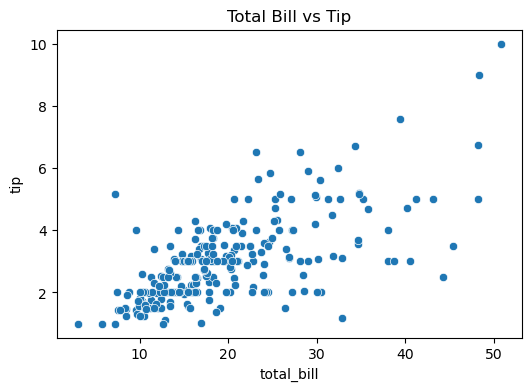

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title('Total Bill vs Tip')
plt.show()

### Bar Plot: Average Tip by Day

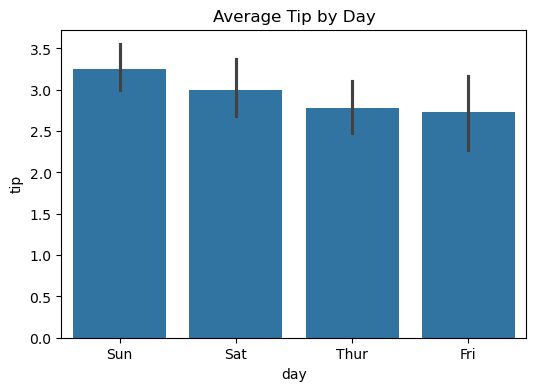

In [20]:
plt.figure(figsize=(6,4))
sns.barplot(x='day', y='tip', data=df)
plt.title('Average Tip by Day')
plt.show()

### Histogram: Distribution of Total Bill

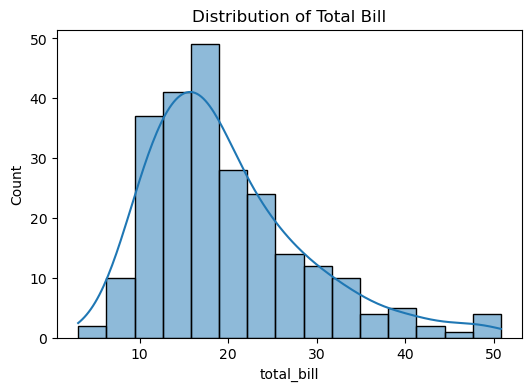

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df['total_bill'], bins=15, kde=True)
plt.title('Distribution of Total Bill')
plt.show()

### Count Plot: Customer Count by Day

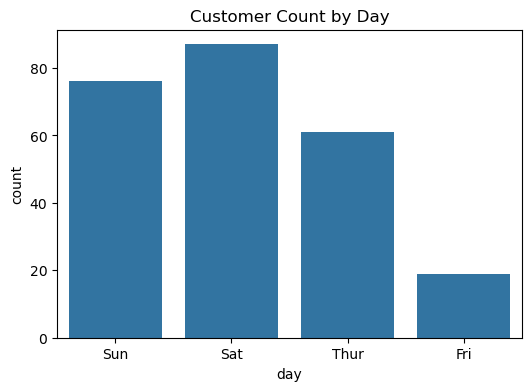

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='day', data=df)
plt.title('Customer Count by Day')
plt.show()

## Outlier Detection

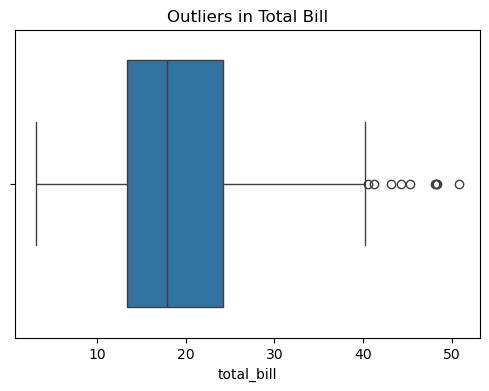

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['total_bill'])
plt.title('Outliers in Total Bill')
plt.show()

## Outlier Removal using IQR Method

In [24]:
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['total_bill'] >= lower_bound) & (df['total_bill'] <= upper_bound)]
df_clean.shape

(234, 7)